In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
data=pd.read_csv(r"C:\Users\kumar\Downloads\Ice_cream selling data.csv")

In [3]:
df=data.copy()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [5]:
df.duplicated().sum()

np.int64(0)

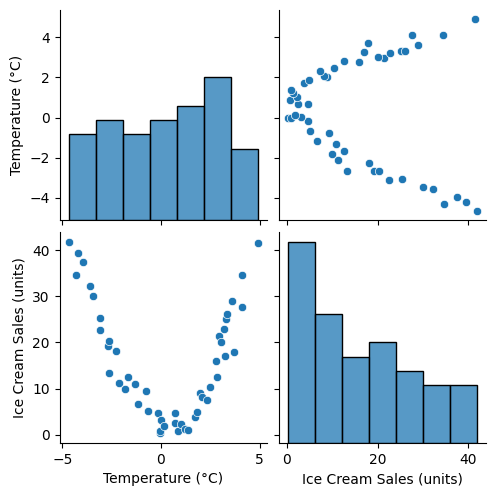

In [6]:
sns.pairplot(data=df)
plt.show()

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [8]:
x=df[["Temperature (°C)"]]
Y=df["Ice Cream Sales (units)"]

In [9]:
pf=PolynomialFeatures(degree=3)

In [10]:
pf.fit(x)

,degree,3
,interaction_only,False
,include_bias,True
,order,'C'


In [11]:
X=pd.DataFrame(pf.transform(x))

In [12]:

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,random_state=42,test_size=0.2)

In [13]:
lr=LinearRegression()

In [14]:
lr.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
lr.score(X_test,Y_test)

0.8405107685716909

In [16]:
from sklearn.metrics import mean_absolute_error,mean_absolute_error,root_mean_squared_error,mean_squared_error

In [17]:
np.sqrt(mean_squared_error(Y_test,lr.predict(X_test)))

np.float64(3.8884456343415086)

In [18]:
from sklearn.tree import DecisionTreeRegressor
dc=DecisionTreeRegressor(max_depth=9)
dc.fit(X_train,Y_train)
dc.score(X_test,Y_test)

0.7386790751494965

In [19]:
np.sqrt(mean_squared_error(Y_test,dc.predict(X_test)))


np.float64(4.977341532974235)

In [20]:
"""for i in range(1,21):
    dc=DecisionTreeRegressor(max_depth=i)
    dc.fit(X_train,Y_train)
    print(dc.score(X_test,Y_test),i)"""

'for i in range(1,21):\n    dc=DecisionTreeRegressor(max_depth=i)\n    dc.fit(X_train,Y_train)\n    print(dc.score(X_test,Y_test),i)'

In [21]:
from sklearn.neighbors import KNeighborsRegressor
kn=KNeighborsRegressor(8)
kn.fit(X_train,Y_train)
kn.score(X_test,Y_test)

0.883649149713231

In [22]:
"""for i in range(1,21):
    kn=KNeighborsRegressor(i)
    kn.fit(X_train,Y_train)
    print(kn.score(X_test,Y_test),     i)"""

'for i in range(1,21):\n    kn=KNeighborsRegressor(i)\n    kn.fit(X_train,Y_train)\n    print(kn.score(X_test,Y_test),     i)'

In [23]:
np.sqrt(mean_squared_error(Y_test,kn.predict(X_test)))

np.float64(3.3212007661367062)

In [24]:
from sklearn.svm import SVR
svm=SVR(kernel='linear')
svm.fit(X_train,Y_train)
svm.score(X_test,Y_test)

0.8097471158830848

In [25]:
np.sqrt(mean_squared_error(Y_test,svm.predict(X_test)))


np.float64(4.246938512428687)

In [26]:
from sklearn.ensemble import VotingRegressor

In [27]:
list=[("lr1",LinearRegression()),("kn1",KNeighborsRegressor()),("svc1",SVR())]

In [28]:
vt=VotingRegressor(estimators=list)
vt.fit(X_train,Y_train)

,estimators,"[('lr1', ...), ('kn1', ...), ...]"
,weights,None
,n_jobs,None
,verbose,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
,n_neighbors,5
,weights,'uniform'


In [33]:
dic={"lr":lr.predict(X_test),"kn":kn.predict(X_test),"svm":svm.predict(X_test),"pre":vt.predict(X_test),"actual":Y_test}


In [34]:
dff=pd.DataFrame(dic)

In [35]:
dff

,lr,kn,svm,pre,actual
13,11.261738,8.255089,12.361717,12.030467,10.012868
45,26.152297,22.453227,27.136666,24.521352,17.843957
47,32.942397,26.071550,34.680695,27.260815,27.698383
44,24.799403,22.453227,25.643742,22.899875,28.912188
17,5.018979,3.969630,5.495216,6.433936,9.392969
27,3.432486,2.044458,3.019311,5.758490,2.313806
26,3.087805,2.044458,2.716742,5.580706,0.789974
25,2.790019,2.044458,2.480883,5.486387,4.625689
31,7.017131,4.382862,6.548103,7.865147,4.857988
19,3.091755,2.761459,3.190881,5.769888,4.673643
